In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/AI_vs_Real_dataset.zip"
extract_path = "/content/AI_vs_Real_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Extraction complete")
print(os.listdir(extract_path))


✅ Extraction complete
['AI_vs_Real_dataset']


In [4]:
import os
project_dir = '/content/drive/MyDrive/CV_Project_AI_Detection'
os.makedirs(project_dir, exist_ok=True)
os.makedirs(f'{project_dir}/models', exist_ok=True)
os.makedirs(f'{project_dir}/results', exist_ok=True)
print(f"Project directory created: {project_dir}")

Project directory created: /content/drive/MyDrive/CV_Project_AI_Detection


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
from torchvision.utils import make_grid
import timm

from datasets import load_dataset
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import copy
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')


In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n{'='*70}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"{'='*70}\n")


Device: cpu



In [ ]:
class Config:
    # Data parameters
    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 2

    # Model parameters
    MODEL_NAME = 'efficientnet_b0' 
    NUM_CLASSES = 2
    PRETRAINED = True

    # Training parameters
    NUM_EPOCHS = 20
    LEARNING_RATE = 1e-4
    WEIGHT_DECAY = 1e-5

    # Early stopping
    PATIENCE = 3

    # LR Scheduler
    LR_PATIENCE = 3
    LR_FACTOR = 0.5

    # Data split
    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15

    # Paths
    PROJECT_DIR = project_dir
    MODEL_SAVE_PATH = f'{project_dir}/models/best_model.pth'
    RESULTS_PATH = f'{project_dir}/results'

    # Random seed for reproducibility
    SEED = 42

config = Config()

# Set random seeds
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(config.SEED)

print(f"Configuration:")
print(f"  Model: {config.MODEL_NAME}")
print(f"  Image Size: {config.IMAGE_SIZE}x{config.IMAGE_SIZE}")
print(f"  Batch Size: {config.BATCH_SIZE}")
print(f"  Learning Rate: {config.LEARNING_RATE}")
print(f"  Max Epochs: {config.NUM_EPOCHS}")


Configuration:
  Model: efficientnet_b0
  Image Size: 224x224
  Batch Size: 32
  Learning Rate: 0.0001
  Max Epochs: 20


In [8]:
from datasets import load_dataset

try:
    dataset = load_dataset(
        "Parveshiiii/AI-vs-Real",
        verification_mode="no_checks"
    )
    print(" Dataset loaded successfully!")
    print(dataset)
except Exception as e:
    print(" Error loading dataset:", e)


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/205M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/309M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/826M [00:00<?, ?B/s]

data/train-00003-of-00005.parquet:   0%|          | 0.00/805M [00:00<?, ?B/s]

data/train-00004-of-00005.parquet:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9999 [00:00<?, ? examples/s]

 Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'binary_label'],
        num_rows: 13999
    })
})


In [10]:
class AIvsRealDataset(Dataset):
    def __init__(self, hf_dataset, transform=None):
        self.dataset = hf_dataset
        self.transform = transform

        # Auto-detect label and image keys
        if len(self.dataset) > 0:
            sample = self.dataset[0]
            print(f"Dataset keys: {sample.keys()}")

            # Find image key
            image_keys = ['image', 'img', 'picture', 'photo']
            self.image_key = None
            for key in image_keys:
                if key in sample:
                    self.image_key = key
                    break

            # Find label key - UPDATED to include binary_label
            label_keys = ['label', 'binary_label', 'labels', 'class', 'target', 'category']
            self.label_key = None
            for key in label_keys:
                if key in sample:
                    self.label_key = key
                    break

            if self.image_key is None or self.label_key is None:
                print(f"⚠ Warning: Could not auto-detect keys.")
                print(f"Available keys: {list(sample.keys())}")
                print(f"Using defaults: image_key='image', label_key='label'")
                self.image_key = 'image'
                self.label_key = 'label'
            else:
                print(f"✓ Detected - Image key: '{self.image_key}', Label key: '{self.label_key}'")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]

        try:
            image = item[self.image_key]
            label = item[self.label_key]
        except KeyError as e:
            print(f"KeyError: {e}")
            print(f"Available keys: {item.keys()}")
            raise

        # Handle different image types
        if isinstance(image, str):
            # If image is a path, load it
            image = Image.open(image)
        elif not isinstance(image, Image.Image):
            # Try to convert to PIL Image
            image = Image.fromarray(image)

        # Convert to RGB if needed
        if image.mode != 'RGB':
            image = image.convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [11]:
train_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((config.IMAGE_SIZE, config.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [ ]:
full_dataset = dataset['train']  
total_size = len(full_dataset)

train_size = int(config.TRAIN_SPLIT * total_size)
val_size = int(config.VAL_SPLIT * total_size)
test_size = total_size - train_size - val_size

# Create splits
train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(config.SEED)
)

print(f"Dataset splits:")
print(f"  Training: {len(train_dataset)} images")
print(f"  Validation: {len(val_dataset)} images")
print(f"  Testing: {len(test_dataset)} images")


Dataset splits:
  Training: 9799 images
  Validation: 2099 images
  Testing: 2101 images


In [13]:
train_data = AIvsRealDataset(train_dataset, transform=train_transform)
val_data = AIvsRealDataset(val_dataset, transform=test_transform)
test_data = AIvsRealDataset(test_dataset, transform=test_transform)


Dataset keys: dict_keys(['image', 'binary_label'])
✓ Detected - Image key: 'image', Label key: 'binary_label'
Dataset keys: dict_keys(['image', 'binary_label'])
✓ Detected - Image key: 'image', Label key: 'binary_label'
Dataset keys: dict_keys(['image', 'binary_label'])
✓ Detected - Image key: 'image', Label key: 'binary_label'


In [14]:
train_loader = DataLoader(
    train_data,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_data,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True
)


Visualizing sample images...
Labels: ['Real', 'AI-Generated', 'AI-Generated', 'Real', 'Real', 'Real', 'Real', 'Real']


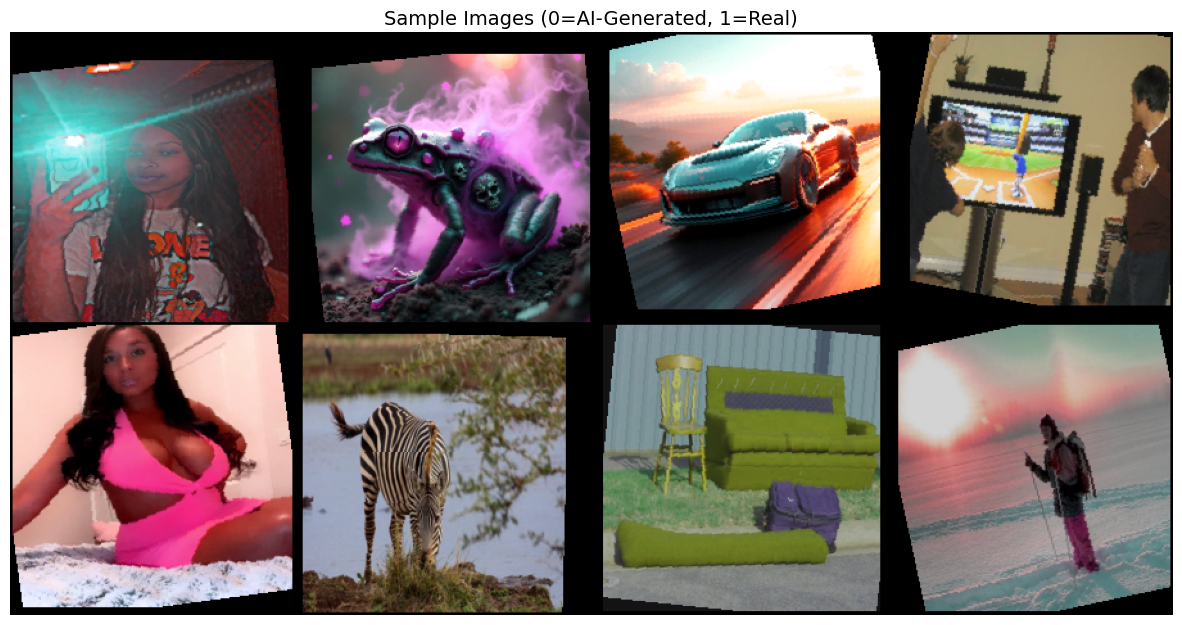

In [15]:
def visualize_samples(loader, num_samples=8):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    # Denormalize
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    images = images * std + mean
    images = torch.clamp(images, 0, 1)

    # Create grid
    grid = make_grid(images[:num_samples], nrow=4, padding=2)

    plt.figure(figsize=(15, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis('off')
    plt.title('Sample Images (0=AI-Generated, 1=Real)', fontsize=14)

    # Print labels
    label_names = ['AI-Generated' if l == 0 else 'Real' for l in labels[:num_samples]]
    print(f"Labels: {label_names}")

    plt.savefig(f'{config.RESULTS_PATH}/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\nVisualizing sample images...")
visualize_samples(train_loader)


In [16]:
class AIDetectionModel(nn.Module):
    def __init__(self, model_name=config.MODEL_NAME, num_classes=config.NUM_CLASSES, pretrained=config.PRETRAINED):
        super(AIDetectionModel, self).__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=num_classes)

    def forward(self, x):
        return self.model(x)

# Initialize model
model = AIDetectionModel().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\nModel: {config.MODEL_NAME}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]


Model: efficientnet_b0
Total parameters: 4,010,110
Trainable parameters: 4,010,110


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=config.LR_PATIENCE,
    factor=config.LR_FACTOR,
)
current_lr = optimizer.param_groups[0]['lr']
print(f"Learning rate: {current_lr:.6f}")


Learning rate: 0.000100


In [18]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    progress_bar = tqdm(loader, desc='Training', leave=False)

    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Update progress bar
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


In [19]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation', leave=False):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


In [20]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs, device, patience):
    print("\n" + "="*70)
    print("STARTING TRAINING")
    print("="*70 + "\n")

    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    epochs_no_improve = 0

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'lr': []
    }

    start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f'\nEpoch {epoch+1}/{num_epochs}')
        print('-' * 70)

        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc, _, _, _ = validate_epoch(model, val_loader, criterion, device)

        # Update scheduler
        scheduler.step(val_loss)

        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']

        # Save history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        epoch_time = time.time() - epoch_start

        print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
        print(f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}')
        print(f'LR: {current_lr:.6f} | Time: {epoch_time:.2f}s')

        # Early stopping and model saving
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0

            # Save best model
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_acc': train_acc,
                'val_acc': val_acc,
            }, config.MODEL_SAVE_PATH)

            print(f'✓ Model saved! (Val Loss: {val_loss:.4f})')
        else:
            epochs_no_improve += 1
            print(f'No improvement for {epochs_no_improve} epoch(s)')

        # Check early stopping
        if epochs_no_improve >= patience:
            print(f'\nEarly stopping triggered after {epoch+1} epochs!')
            break

        # Save checkpoint every 10 epochs
        if (epoch + 1) % 10 == 0:
            checkpoint_path = f'{config.PROJECT_DIR}/models/checkpoint_epoch_{epoch+1}.pth'
            torch.save(model.state_dict(), checkpoint_path)
            print(f'Checkpoint saved: {checkpoint_path}')

    total_time = time.time() - start_time
    print(f'\n{"="*70}')
    print(f'Training completed in {total_time/60:.2f} minutes')
    print(f'Best validation loss: {best_val_loss:.4f}')
    print(f'{"="*70}\n')

    # Load best model weights
    model.load_state_dict(best_model_wts)

    return model, history



STARTING TRAINING


Epoch 1/20
----------------------------------------------------------------------


Train Loss: 0.3277 | Train Acc: 0.9276
Val Loss: 0.1186 | Val Acc: 0.9733
LR: 0.000100 | Time: 2807.07s
✓ Model saved! (Val Loss: 0.1186)

Epoch 2/20
----------------------------------------------------------------------


Train Loss: 0.0778 | Train Acc: 0.9766
Val Loss: 0.0817 | Val Acc: 0.9762
LR: 0.000100 | Time: 2847.61s
✓ Model saved! (Val Loss: 0.0817)

Epoch 3/20
----------------------------------------------------------------------


Train Loss: 0.0423 | Train Acc: 0.9863
Val Loss: 0.0708 | Val Acc: 0.9809
LR: 0.000100 | Time: 2754.98s
✓ Model saved! (Val Loss: 0.0708)

Epoch 4/20
----------------------------------------------------------------------


Train Loss: 0.0259 | Train Acc: 0.9906
Val Loss: 0.0568 | Val Acc: 0.9838
LR: 0.000100 | Time: 2739.87s
✓ Model saved! (Val Loss: 0.0568)

Epoch 5/20
----------------------------------------------------------------------


Train Loss: 0.0176 | Train Acc: 0.9938
Val Loss: 0.0503 | Val Acc: 0.9843
LR: 0.000100 | Time: 2818.89s
✓ Model saved! (Val Loss: 0.0503)

Epoch 6/20
----------------------------------------------------------------------


Train Loss: 0.0122 | Train Acc: 0.9956
Val Loss: 0.0613 | Val Acc: 0.9828
LR: 0.000100 | Time: 2949.83s
No improvement for 1 epoch(s)

Epoch 7/20
----------------------------------------------------------------------


Train Loss: 0.0144 | Train Acc: 0.9948
Val Loss: 0.0561 | Val Acc: 0.9852
LR: 0.000100 | Time: 2919.23s
No improvement for 2 epoch(s)

Epoch 8/20
----------------------------------------------------------------------


Train Loss: 0.0150 | Train Acc: 0.9944
Val Loss: 0.0675 | Val Acc: 0.9781
LR: 0.000100 | Time: 2941.34s
No improvement for 3 epoch(s)

Early stopping triggered after 8 epochs!

Training completed in 379.74 minutes
Best validation loss: 0.0503



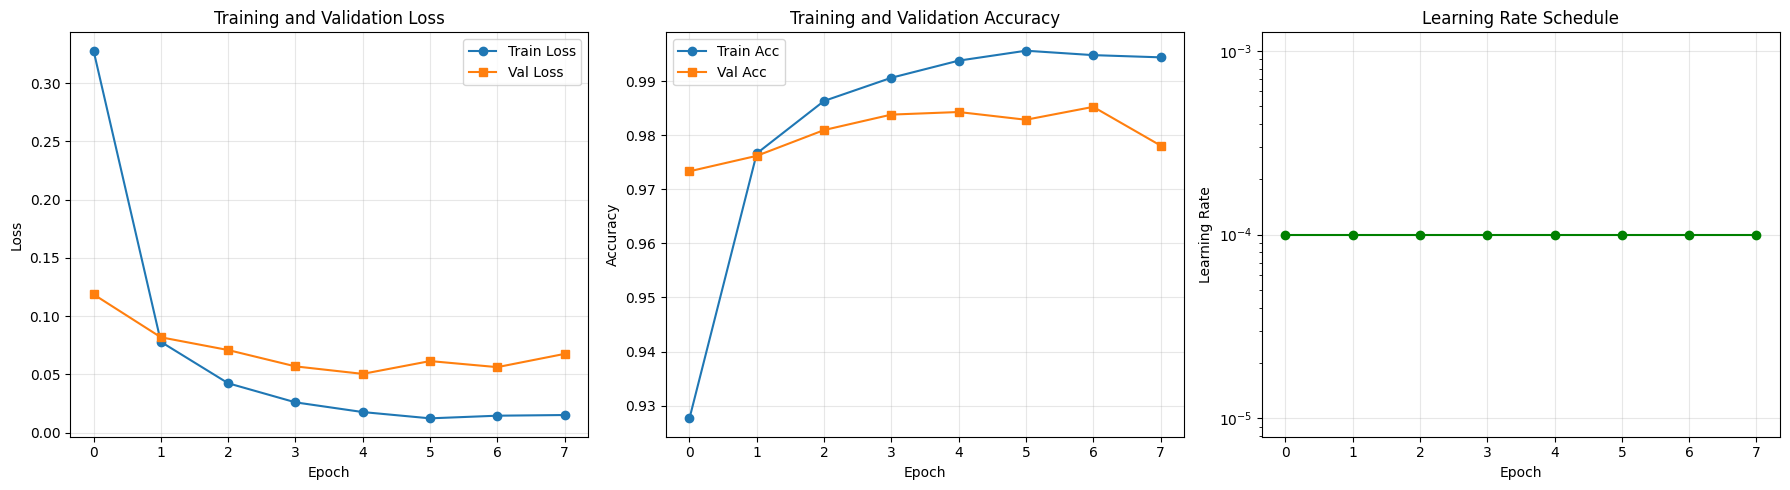

In [21]:
model, history = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    config.NUM_EPOCHS,
    device,
    config.PATIENCE
)

# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
    axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc', marker='o')
    axes[1].plot(history['val_acc'], label='Val Acc', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Learning Rate
    axes[2].plot(history['lr'], marker='o', color='green')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Learning Rate')
    axes[2].set_title('Learning Rate Schedule')
    axes[2].set_yscale('log')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)


In [22]:
checkpoint = torch.load(config.MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

Loaded best model from epoch 5


In [23]:
test_loss, test_acc, test_preds, test_labels, test_probs = validate_epoch(
    model, test_loader, criterion, device
)

print(f'\nTest Results:')
print(f'  Loss: {test_loss:.4f}')
print(f'  Accuracy: {test_acc:.4f}')


Test Results:
  Loss: 0.0517
  Accuracy: 0.9862


In [24]:
test_probs_array = np.array(test_probs)
precision = precision_score(test_labels, test_preds, average='binary')
recall = recall_score(test_labels, test_preds, average='binary')
f1 = f1_score(test_labels, test_preds, average='binary')
auc = roc_auc_score(test_labels, test_probs_array[:, 1])

print(f'\nDetailed Metrics:')
print(f'  Precision: {precision:.4f}')
print(f'  Recall: {recall:.4f}')
print(f'  F1-Score: {f1:.4f}')
print(f'  ROC-AUC: {auc:.4f}')


Detailed Metrics:
  Precision: 0.9938
  Recall: 0.9883
  F1-Score: 0.9910
  ROC-AUC: 0.9984


In [25]:
print('\nClassification Report:')
print(classification_report(test_labels, test_preds,
                          target_names=['AI-Generated', 'Real']))


Classification Report:
              precision    recall  f1-score   support

AI-Generated       0.96      0.98      0.97       483
        Real       0.99      0.99      0.99      1618

    accuracy                           0.99      2101
   macro avg       0.98      0.98      0.98      2101
weighted avg       0.99      0.99      0.99      2101



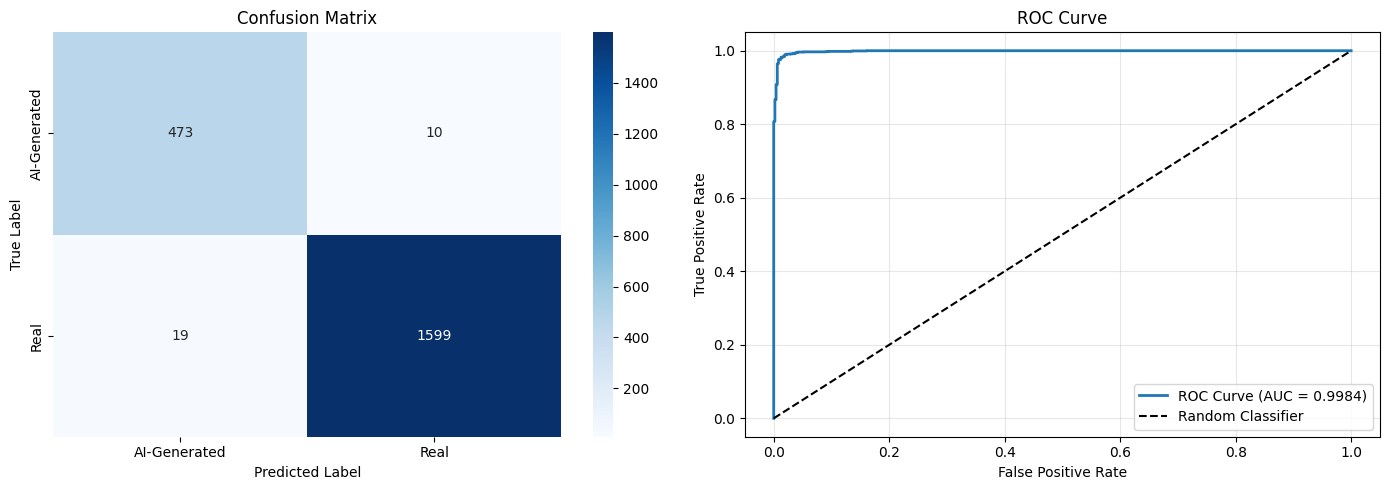

In [31]:

cm = confusion_matrix(test_labels, test_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['AI-Generated', 'Real'],
            yticklabels=['AI-Generated', 'Real'])
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(test_labels, test_probs_array[:, 1])
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {auc:.4f})', linewidth=2)
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.RESULTS_PATH}/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Test Loss'],
    'Value': [test_acc, precision, recall, f1, auc, test_loss]
})
results_df.to_csv(f'{config.RESULTS_PATH}/test_results.csv', index=False)
print(f"\nResults saved to: {config.RESULTS_PATH}/test_results.csv")


Results saved to: /content/drive/MyDrive/CV_Project_AI_Detection/results/test_results.csv


In [34]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 47.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=2d5c1d0b1b850eeaea42d75b107452ac39be4daa2f9a0f0fc35246c511c99823
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [35]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


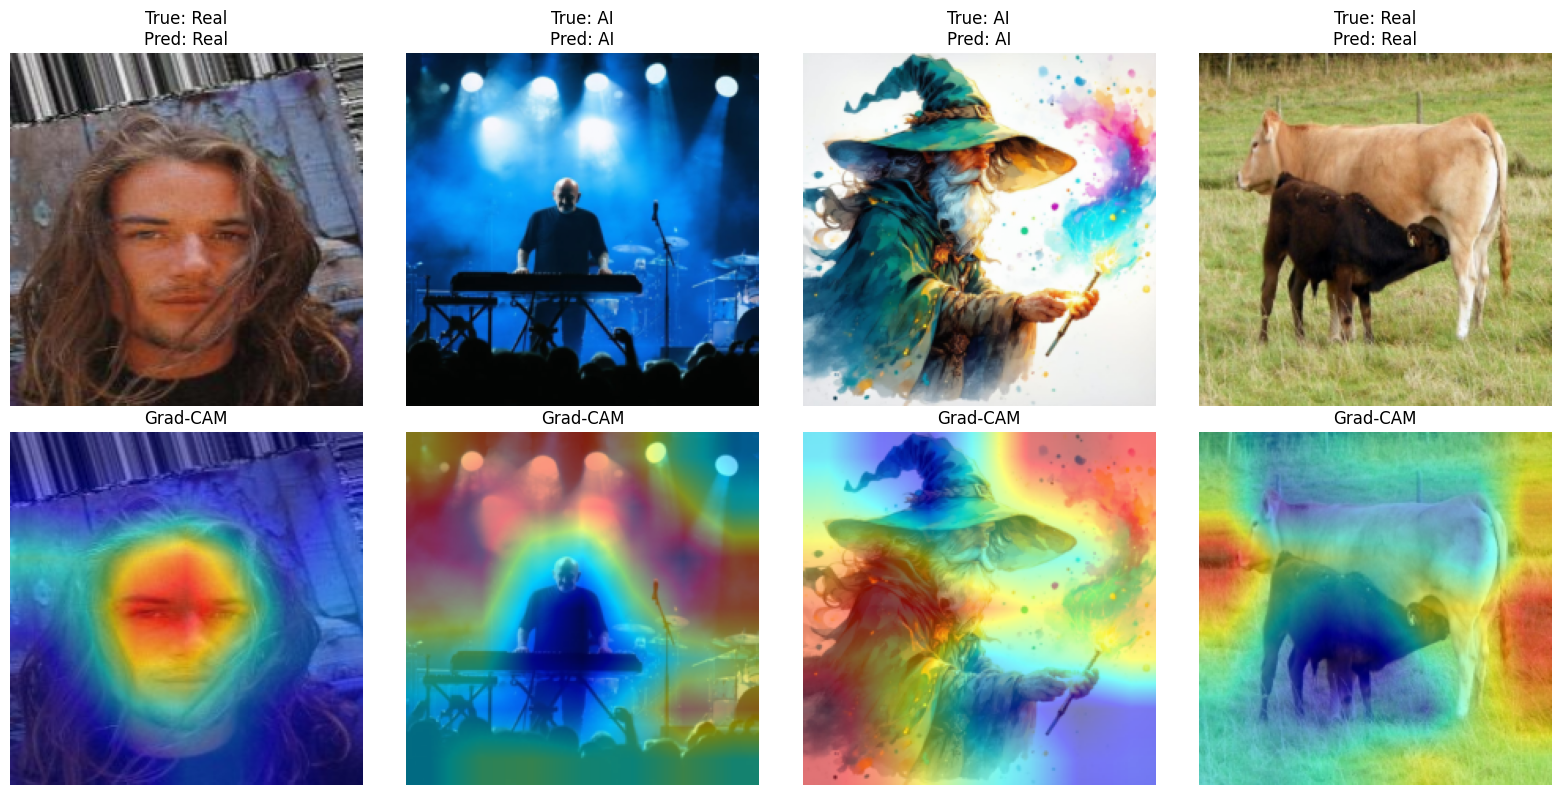

In [36]:
target_layers = [model.model.conv_head]

# Create GradCAM object
cam = GradCAM(model=model, target_layers=target_layers)

# Get some test images
def visualize_gradcam(model, test_loader, cam, num_images=4):
    model.eval()

    # Get a batch
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    fig, axes = plt.subplots(2, num_images, figsize=(16, 8))

    for idx in range(num_images):
        img_tensor = images[idx].unsqueeze(0).to(device)
        true_label = labels[idx].item()

        # Get prediction
        with torch.no_grad():
            output = model(img_tensor)
            pred = torch.argmax(output, dim=1).item()

        # Generate CAM
        targets = [ClassifierOutputTarget(pred)]
        grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]

        # Denormalize image for visualization
        img = images[idx].cpu()
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = img * std + mean
        img = torch.clamp(img, 0, 1)
        img_np = img.permute(1, 2, 0).numpy()

        # Create CAM visualization
        cam_image = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

        # Plot original
        axes[0, idx].imshow(img_np)
        axes[0, idx].axis('off')
        axes[0, idx].set_title(f'True: {"Real" if true_label == 1 else "AI"}\nPred: {"Real" if pred == 1 else "AI"}')

        # Plot CAM
        axes[1, idx].imshow(cam_image)
        axes[1, idx].axis('off')
        axes[1, idx].set_title('Grad-CAM')

    plt.tight_layout()
    plt.savefig(f'{config.RESULTS_PATH}/gradcam_visualization.png', dpi=150, bbox_inches='tight')
    plt.show()

visualize_gradcam(model, test_loader, cam, num_images=4)


In [37]:
print(f"\nAll results saved to: {config.PROJECT_DIR}")
print(f"\nFiles generated:")
print(f"  ✓ Best model: {config.MODEL_SAVE_PATH}")
print(f"  ✓ Training history plot: {config.RESULTS_PATH}/training_history.png")
print(f"  ✓ Evaluation metrics: {config.RESULTS_PATH}/evaluation_metrics.png")
print(f"  ✓ Grad-CAM visualizations: {config.RESULTS_PATH}/gradcam_visualization.png")
print(f"  ✓ Test results CSV: {config.RESULTS_PATH}/test_results.csv")
print(f"\nFinal Test Metrics:")
print(f"  Accuracy: {test_acc:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-Score: {f1:.4f}")
print(f"  ROC-AUC: {auc:.4f}")
print("\n" + "="*70)


All results saved to: /content/drive/MyDrive/CV_Project_AI_Detection

Files generated:
  ✓ Best model: /content/drive/MyDrive/CV_Project_AI_Detection/models/best_model.pth
  ✓ Training history plot: /content/drive/MyDrive/CV_Project_AI_Detection/results/training_history.png
  ✓ Evaluation metrics: /content/drive/MyDrive/CV_Project_AI_Detection/results/evaluation_metrics.png
  ✓ Grad-CAM visualizations: /content/drive/MyDrive/CV_Project_AI_Detection/results/gradcam_visualization.png
  ✓ Test results CSV: /content/drive/MyDrive/CV_Project_AI_Detection/results/test_results.csv

Final Test Metrics:
  Accuracy: 0.9862
  Precision: 0.9938
  Recall: 0.9883
  F1-Score: 0.9910
  ROC-AUC: 0.9984

